# Randomized Benchmarking with ibm_fez Noise Model

This notebook implements:
1. Noise model extraction from IBM Quantum hardware (ibm_fez)
2. Standard Randomized Benchmarking (RB) to extract depolarizing parameter p
3. Interleaved Randomized Benchmarking (IRB) to characterize specific gates
4. Simulation and data analysis

## Setup and Imports

In [1]:
%pip install --quiet qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.optimize
from collections import deque
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
import os

# Import NoiseModel with fallback
try:
    from qiskit_aer.noise import NoiseModel
except Exception:
    try:
        from qiskit.providers.aer.noise import NoiseModel
    except Exception:
        raise ImportError("NoiseModel import failed — install qiskit-aer")

print("Imports successful!")

Imports successful!


## 1. Create Noise Model from ibm_fez Hardware

In [3]:
IBM_QUANTUM_TOKEN = "r4IqbTTUxpez5jP4UIcfKOo-f8xki_93SKdFYCNUASB7"

#Connect to IBM Quantum service
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)
backend = service.backend("ibm_fez")

#Extract noise model from real hardware
noise_model = NoiseModel.from_backend(backend)

print(f"✓ Connected to {backend.name}")
print(f"✓ Noise model extracted: {len(noise_model.to_dict().get('errors', {}))} error definitions")
print(f"  Basis gates: {noise_model.basis_gates}")

qiskit_runtime_service._discover_account:WARNING:2026-01-17 00:09:55,375: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-01-17 00:09:58,534: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-17 00:09:58,535: Using instance: open-instance, plan: open


✓ Connected to ibm_fez
✓ Noise model extracted: 1132 error definitions
  Basis gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']


## 2. Generate Single-Qubit Clifford Group

In [4]:
def normalize_up_to_global_phase(U):
    """Normalize unitary matrix to remove global phase."""
    idx = np.argmax(np.abs(U))
    phase = np.angle(U.flatten()[idx])
    return U * np.exp(-1j * phase)

def generate_single_qubit_cliffords():
    """Generate all 24 single-qubit Clifford gates using H and S."""
    generating_gates = {'H': lambda qc: qc.h(0), 'S': lambda qc: qc.s(0)}
    seen_matrices = []
    circuits = []
    queue = deque([QuantumCircuit(1)])  # Start with identity
    
    while queue:
        qc = queue.popleft()
        U = Operator(qc).data
        U_norm = normalize_up_to_global_phase(U)
        
        if any(np.allclose(U_norm, M) for M in seen_matrices):
            continue
        seen_matrices.append(U_norm)
        circuits.append(qc)
        
        for gate_func in generating_gates.values():
            new_qc = qc.copy()
            gate_func(new_qc)
            queue.append(new_qc)
    
    assert len(circuits) == 24, f"Expected 24 Cliffords, found {len(circuits)}"
    return circuits

# Generate Cliffords and compute inverses
cliffords_list = generate_single_qubit_cliffords()
cliffords_matrices = [normalize_up_to_global_phase(Operator(qc).data) for qc in cliffords_list]
I2 = np.eye(2, dtype=complex)

cliffords_inverses = {}
for i, U_i in enumerate(cliffords_matrices):
    for j, U_j in enumerate(cliffords_matrices):
        product_norm = normalize_up_to_global_phase(U_i @ U_j)
        if np.allclose(product_norm, I2):
            cliffords_inverses[i] = j
            break

print(f"✓ Generated {len(cliffords_list)} Clifford circuits")
print(f"✓ Computed inverse mapping for all Cliffords")

✓ Generated 24 Clifford circuits
✓ Computed inverse mapping for all Cliffords


## 3. Create RB/IRB Sequence Function

In [5]:
def create_rb_sequence(clifford_circuits, cliffords_matrices, m, target_gate_circuit=None, seed=None):
    """
    Create an RB or IRB sequence.
    
    Args:
        clifford_circuits: List of 24 Clifford QuantumCircuits
        cliffords_matrices: List of normalized Clifford unitary matrices
        m: Sequence length (number of random Cliffords)
        target_gate_circuit: Gate to interleave (None for standard RB)
        seed: Random seed for reproducibility
    
    Returns:
        QuantumCircuit with measurement
    
    Sequence structure:
        Standard RB:  C_1, C_2, ..., C_m, C_inverse, measure
        Interleaved:  C_1, G, C_2, G, ..., C_m, G, C_inverse, measure
    """
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(clifford_circuits), size=m, replace=True)
    
    qc = QuantumCircuit(1, 1)
    
    # Apply random Cliffords (and optionally interleave target gate)
    for idx in indices:
        qc.compose(clifford_circuits[idx], inplace=True)
        if target_gate_circuit is not None:
            qc.compose(target_gate_circuit, inplace=True)
    
    # Compute inverse Clifford that returns to |0⟩
    U_fwd = Operator(qc).data
    U_fwd_norm = normalize_up_to_global_phase(U_fwd)
    I = np.eye(2, dtype=complex)
    
    inverse_idx = None
    for j, U_j in enumerate(cliffords_matrices):
        product = normalize_up_to_global_phase(U_fwd_norm @ U_j)
        if np.allclose(product, I):
            inverse_idx = j
            break
    
    if inverse_idx is None:
        raise RuntimeError("Could not find inverse Clifford")
    
    qc.compose(clifford_circuits[inverse_idx], inplace=True)
    qc.measure(0, 0)
    return qc

print("✓ RB/IRB sequence function defined")

✓ RB/IRB sequence function defined


In [6]:
# Helper: extract gate sequence from a circuit

def extract_gate_sequence(qc, include_measure=False):
    """Return a tuple of gate operation names in order.
    Set include_measure=True to include 'measure' operations."""
    names = []
    for instruction, qargs, cargs in qc.data:
        name = instruction.name
        if not include_measure and name == 'measure':
            continue
        names.append(name)
    return tuple(names)


## 4. Standard RB - Extract Depolarizing Parameter p

In [8]:
# Standard RB: No target gate interleaving
sequence_lengths = [2, 4, 6, 8, 12]
num_sequences = 30
shots = 1024
seed_base = 54321

sim = AerSimulator()
survival_probs_rb = []

print("Running Standard RB...")
for m in sequence_lengths:
    probs = []
    for k in range(num_sequences):
        seed = seed_base + m * 1000 + k
        rb_seq = create_rb_sequence(
            clifford_circuits=cliffords_list,
            cliffords_matrices=cliffords_matrices,
            m=m,
            target_gate_circuit=None,  # No interleaving
            seed=seed
        )
        rb_seq_transpiled = transpile(rb_seq, backend=backend)
        job = sim.run(rb_seq_transpiled, shots=shots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts()
        prob = counts.get('0', 0) / shots
        probs.append(prob)
    avg_prob = np.mean(probs)
    survival_probs_rb.append(avg_prob)
    print(f"  m={m:2d}: F_seq = {avg_prob:.6f}")

print("✓ Standard RB complete")

Running Standard RB...
  m= 2: F_seq = 0.997038
  m= 4: F_seq = 0.997624
  m= 6: F_seq = 0.996745
  m= 8: F_seq = 0.996940
  m=12: F_seq = 0.997331
✓ Standard RB complete


In [9]:
# Fit Standard RB data to F_seq(m) = A * p^m + B
m_vals = np.array(sequence_lengths)
F_seq_rb = np.array(survival_probs_rb)

def fit_func(m, A, p, B):
    return A * p**m + B

params_rb, _ = scipy.optimize.curve_fit(
    fit_func, m_vals, F_seq_rb,
    p0=[0.95, 0.98, 0.05],
    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])
)
A_rb, p_rb, B_rb = params_rb
r_rb = (2 - 1) / 2 * (1 - p_rb)  # Average error per Clifford

print(f"\n=== Standard RB Results ===")
print(f"Fit: F_seq(m) = {A_rb:.6f} × {p_rb:.8f}^m + {B_rb:.6f}")
print(f"Depolarizing parameter p: {p_rb:.8f}")
print(f"Average error per Clifford r: {r_rb:.8f} ({r_rb*100:.6f}%)")
print(f"Gate fidelity: {(1-r_rb)*100:.6f}%")


=== Standard RB Results ===
Fit: F_seq(m) = 0.698991 × 0.99990000^m + 0.298591
Depolarizing parameter p: 0.99990000
Average error per Clifford r: 0.00005000 (0.005000%)
Gate fidelity: 99.995000%


In [16]:
# First-order RB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1

def fit_func_first_order(m, A1, p1, C1, B1):
    m = np.asarray(m, dtype=float)
    return A1 * (p1 ** m) + C1 * (m - 1) * (p1 ** (m - 2)) + B1

try:
    params_rb_fo, _ = scipy.optimize.curve_fit(
        fit_func_first_order,
        m_vals,
        F_seq_rb,
        p0=[0.5, 0.99, 0.01, 0.5],
        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    )
    A1_rb, p1_rb, C1_rb, B1_rb = params_rb_fo
    r1_rb = (2 - 1) / 2 * (1 - p1_rb)
    print("\n=== Standard RB First-Order Fit ===")
    print(f"Fit: F_seq^(1)(m) = {A1_rb:.6f} * {p1_rb:.8f}^m + {C1_rb:.6f} * (m-1) * {p1_rb:.8f}^(m-2) + {B1_rb:.6f}")
    print(f"Depolarizing parameter p (first-order): {p1_rb:.8f}")
    print(f"Average error per Clifford r (first-order): {r1_rb:.8f} ({r1_rb*100:.6f}%)")
except Exception as e:
    print(f"First-order RB fit failed: {e}")


=== Standard RB First-Order Fit ===
Fit: F_seq^(1)(m) = 0.487851 * 0.99981987^m + 0.000091 * (m-1) * 0.99981987^(m-2) + 0.509355
Depolarizing parameter p (first-order): 0.99981987
Average error per Clifford r (first-order): 0.00009006 (0.009006%)


## 5. Interleaved RB - Characterize RX Gate

In [11]:
# Define target gate (RX(pi/2) gate)
target_RX = QuantumCircuit(1)
target_RX.rx(np.pi/2, 0)

# Interleaved RB: RX(pi/2) gate after each Clifford
survival_probs_irb = []

print("Running Interleaved RB (RX(pi/2) gate)...")
for m in sequence_lengths:
    probs = []
    for k in range(num_sequences):
        seed = seed_base + m * 1000 + k + 99999
        irb_seq = create_rb_sequence(
            clifford_circuits=cliffords_list,
            cliffords_matrices=cliffords_matrices,
            m=m,
            target_gate_circuit=target_RX,  # Interleave RX(pi/2) gate
            seed=seed
        )
        irb_seq_transpiled = transpile(irb_seq, backend=backend)
        job = sim.run(irb_seq_transpiled, shots=shots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts()
        prob = counts.get('0', 0) / shots
        probs.append(prob)
    avg_prob = np.mean(probs)
    survival_probs_irb.append(avg_prob)
    print(f"  m={m:2d}: F_seq = {avg_prob:.6f}")

print("✓ Interleaved RB complete")

Running Interleaved RB (RX(pi/2) gate)...
  m= 2: F_seq = 0.996712
  m= 4: F_seq = 0.996615
  m= 6: F_seq = 0.996842
  m= 8: F_seq = 0.997493
  m=12: F_seq = 0.996549
✓ Interleaved RB complete


In [12]:
# Fit Interleaved RB data
F_seq_irb = np.array(survival_probs_irb)

params_irb, _ = scipy.optimize.curve_fit(
    fit_func, m_vals, F_seq_irb,
    p0=[0.95, 0.98, 0.05],
    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])
)
A_irb, p_irb, B_irb = params_irb
r_irb = (2 - 1) / 2 * (1 - p_irb)

# Calculate RX gate error from comparison with standard RB
# Formula: p_irb = p_rb * p_RX (approximately)
p_RX = min(p_irb / p_rb if p_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]
r_RX = (2 - 1) / 2 * (1 - p_RX)

print(f"\n=== Interleaved RB Results (RX Gate) ===")
print(f"Fit: F_seq(m) = {A_irb:.6f} × {p_irb:.8f}^m + {B_irb:.6f}")
print(f"Depolarizing parameter p_irb: {p_irb:.8f}")
print(f"Average error per (Clifford+RX) r_irb: {r_irb:.8f} ({r_irb*100:.6f}%)")
print(f"\nRX gate specific:")
print(f"  p_RX = p_irb / p_rb = {p_RX:.8f}")
print(f"  RX gate error r_RX: {r_RX:.8f} ({r_RX*100:.6f}%)")
print(f"  RX gate fidelity: {(1-r_RX)*100:.6f}%")


=== Interleaved RB Results (RX Gate) ===
Fit: F_seq(m) = 0.698509 × 0.99990000^m + 0.298780
Depolarizing parameter p_irb: 0.99990000
Average error per (Clifford+RX) r_irb: 0.00005000 (0.005000%)

RX gate specific:
  p_RX = p_irb / p_rb = 1.00000000
  RX gate error r_RX: 0.00000000 (0.000000%)
  RX gate fidelity: 100.000000%


In [17]:
# First-order IRB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1
try:
    params_irb_fo, _ = scipy.optimize.curve_fit(
        fit_func_first_order,
        m_vals,
        F_seq_irb,
        p0=[0.5, 0.99, 0.01, 0.5],
        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    )
    A1_irb, p1_irb, C1_irb, B1_irb = params_irb_fo
    r1_irb = (2 - 1) / 2 * (1 - p1_irb)
    # Gate-specific first-order parameter via p_RX1 ≈ p1_irb / p1_rb
    p1_RX = min(p1_irb / p1_rb if p1_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]
    r1_RX = (2 - 1) / 2 * (1 - p1_RX)
    print("\n=== Interleaved RB First-Order Fit (RX Gate) ===")
    print(f"Fit: F_seq^(1)(m) = {A1_irb:.6f} * {p1_irb:.8f}^m + {C1_irb:.6f} * (m-1) * {p1_irb:.8f}^(m-2) + {B1_irb:.6f}")
    print(f"Depolarizing parameter p_irb (first-order): {p1_irb:.8f}")
    print(f"Average error per (Clifford+RX) r_irb (first-order): {r1_irb:.8f} ({r1_irb*100:.6f}%)")
    print(f"\nRX gate (first-order): p_RX1 = p1_irb / p1_rb = {p1_RX:.8f}")
    print(f"RX gate error r_RX1: {r1_RX:.8f} ({r1_RX*100:.6f}%) | Fidelity: {(1-r1_RX)*100:.6f}%")
except Exception as e:
    print(f"First-order IRB fit failed: {e}")


=== Interleaved RB First-Order Fit (RX Gate) ===
Fit: F_seq^(1)(m) = 0.648785 * 0.99214165^m + 0.005299 * (m-1) * 0.99214165^(m-2) + 0.352602
Depolarizing parameter p_irb (first-order): 0.99214165
Average error per (Clifford+RX) r_irb (first-order): 0.00392917 (0.392917%)

RX gate (first-order): p_RX1 = p1_irb / p1_rb = 0.99232040
RX gate error r_RX1: 0.00383980 (0.383980%) | Fidelity: 99.616020%


## 6. Visualization and Data Summary

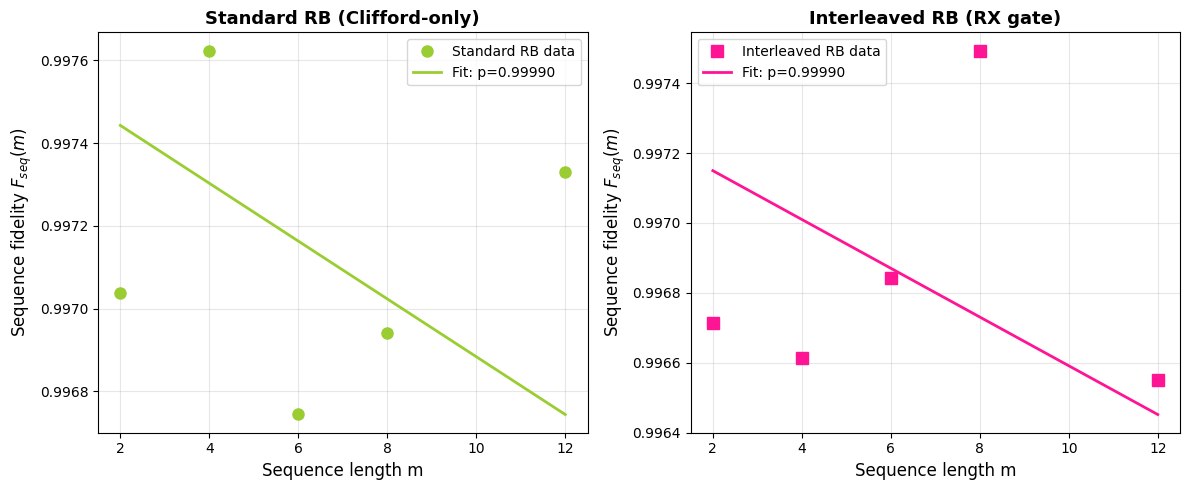

In [13]:
# Plot Standard RB and Interleaved RB comparison
plt.figure(figsize=(12, 5))

# Standard RB plot
plt.subplot(1, 2, 1)
plt.plot(m_vals, F_seq_rb, 'o', markersize=8, label='Standard RB data', color='yellowgreen')
plt.plot(m_vals, fit_func(m_vals, *params_rb), '-', linewidth=2, label=f'Fit: p={p_rb:.5f}', color='yellowgreen')
plt.xlabel('Sequence length m', fontsize=12)
plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)
plt.title('Standard RB (Clifford-only)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Interleaved RB plot
plt.subplot(1, 2, 2)
plt.plot(m_vals, F_seq_irb, 's', markersize=8, label='Interleaved RB data', color='deeppink')
plt.plot(m_vals, fit_func(m_vals, *params_irb), '-', linewidth=2, label=f'Fit: p={p_irb:.5f}', color='deeppink')
plt.xlabel('Sequence length m', fontsize=12)
plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)
plt.title('Interleaved RB (RX gate)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_70953/3543731753.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instruction, qargs, cargs in qc.data:


Interleaved RB (RX gate) — actual sequence used during run
m = 12, sequence index k = 0, seed = 166320
Gate tuple: ('s', 'h', 'rx', 'h', 's', 'rx', 's', 'h', 'rx', 'h', 's', 'h', 's', 's', 's', 'rx', 's', 'h', 's', 's', 'rx', 'h', 's', 's', 'h', 's', 's', 'rx', 'h', 's', 'h', 's', 'rx', 's', 's', 's', 'rx', 'h', 's', 's', 'rx', 's', 'h', 's', 's', 'h', 'rx', 'h', 's', 'h', 's', 's', 's', 'rx', 'h', 's', 'rx', 's', 'h', 's')
Circuit depth: 61
Number of gates (incl. measure): 61


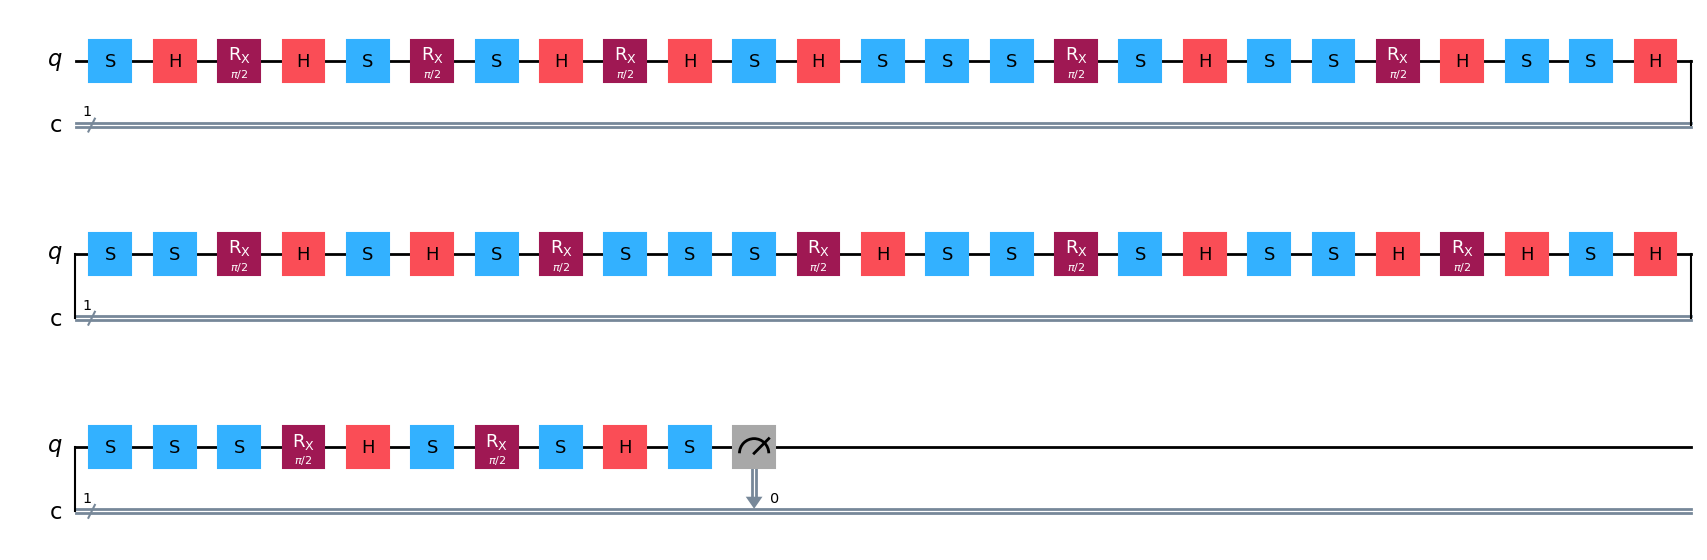

In [23]:
# Show one of the actual sequences used in the RB/IRB runs (same seeds as above)
# Adjust m_view and k_view if you want a different sequence; interleaved=True shows RX-gate IRB.
m_view = 12         # must be in sequence_lengths
k_view = 0         # 0-based index into the num_sequences draws
interleaved = True # False = Standard RB, True = Interleaved RB (RX gate)

if m_view not in sequence_lengths:
    raise ValueError(f"m_view {m_view} not in sequence_lengths {sequence_lengths}")
if not (0 <= k_view < num_sequences):
    raise ValueError(f"k_view {k_view} must be between 0 and {num_sequences-1}")

seed_offset = 99999 if interleaved else 0
seed = seed_base + m_view * 1000 + k_view + seed_offset

seq = create_rb_sequence(
    clifford_circuits=cliffords_list,
    cliffords_matrices=cliffords_matrices,
    m=m_view,
    target_gate_circuit=(target_RX if interleaved else None),
    seed=seed,
)

seq_label = "Interleaved RB (RX gate)" if interleaved else "Standard RB"
seq_gate_tuple = extract_gate_sequence(seq)

print(f"{seq_label} — actual sequence used during run")
print(f"m = {m_view}, sequence index k = {k_view}, seed = {seed}")
print(f"Gate tuple: {seq_gate_tuple}")
print(f"Circuit depth: {seq.depth()}")
print(f"Number of gates (incl. measure): {len(seq.data)}")

%matplotlib inline
fig = seq.draw('mpl')
plt.show()

In [15]:
#Debug Fit order 1
print("m_vals:", m_vals)
print("F_seq_irb:", F_seq_irb)
print("p0:", [0.5, 0.99, 0.01, 0.5])
print("bounds:", ([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0]))

m_vals: [ 2  4  6  8 12]
F_seq_irb: [0.99671224 0.99661458 0.99684245 0.99749349 0.99654948]
p0: [0.5, 0.99, 0.01, 0.5]
bounds: ([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
